# Music Recommendation EDA

This notebook analyses the Million Playlist Dataset (MPD) to inform the choice of collaborative filtering (CF) model for a music recommendation system.

**Questions we need to answer:**
- How sparse is the playlist-track interaction matrix? (determines viable model families)
- Does track popularity follow a power law? (determines whether popularity bias is a problem)
- How severe is the cold-start problem? (determines whether a content-based fallback is needed)
- What does the distribution of tracks per playlist look like? (informs train/test split strategy)

**Sections:**
1. Data Loading
2. Data Cleaning
3. Interaction Matrix Properties
4. Playlist Level Analysis
5. Track Level Analysis
6. Artist and Album Analysis
7. CF Model Selection Summary

## Imports

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
from dotenv import load_dotenv

%matplotlib inline

## 1. Data Loading

Load the three tables from Supabase. The connection is opened and closed in a single function so no connection leaks into the rest of the notebook.

In [2]:
def load_data():
    load_dotenv("../../../credentials/.env")

    conn = psycopg2.connect(
        host=os.environ["SUPABASE_HOST"],
        port=os.environ.get("SUPABASE_PORT", 6543),
        dbname=os.environ.get("SUPABASE_DB", "postgres"),
        user=os.environ["SUPABASE_USER"],
        password=os.environ["SUPABASE_PASSWORD"],
        sslmode="require",
    )

    playlists_df = pd.read_sql_query("SELECT * FROM playlists", conn)
    tracks_df = pd.read_sql_query("SELECT * FROM tracks", conn)
    playlist_tracks_df = pd.read_sql_query("SELECT * FROM playlist_tracks", conn)

    conn.close()

    return playlists_df, tracks_df, playlist_tracks_df

In [3]:
playlists_df, tracks_df, playlist_tracks_df = load_data()

/var/folders/c8/d8w55bgd5sd503rlpx_ymlp00000gn/T/ipykernel_28978/3980781776.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  playlists_df = pd.read_sql_query("SELECT * FROM playlists", conn)
/var/folders/c8/d8w55bgd5sd503rlpx_ymlp00000gn/T/ipykernel_28978/3980781776.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tracks_df = pd.read_sql_query("SELECT * FROM tracks", conn)
/var/folders/c8/d8w55bgd5sd503rlpx_ymlp00000gn/T/ipykernel_28978/3980781776.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  playlist_tracks_

In [4]:
print("Playlists:")
print("Total number of rows:", len(playlists_df))
display(playlists_df.head())

print("\nTracks:")
print("Total number of rows:", len(tracks_df))
display(tracks_df.head())

print("\nPlaylist-Tracks:")
print("Total number of rows:", len(playlist_tracks_df))
display(playlist_tracks_df.head())

Playlists:
Total number of rows: 3000


,playlist_id,playlist_name,collaborative,modified_at,num_tracks,num_albums,num_followers,num_edits,duration_ms,ingested_at
0,376000,Cheese,False,2017-03-29 00:00:00+00:00,95,78,2,15,25518141,2026-04-11 23:25:59.441207+00:00
1,376001,05,False,2017-09-30 00:00:00+00:00,102,96,1,37,23564243,2026-04-11 23:25:59.441207+00:00
2,376002,fire,False,2017-06-28 00:00:00+00:00,30,26,3,16,6106184,2026-04-11 23:25:59.441207+00:00
3,376003,Slow music,False,2013-10-23 00:00:00+00:00,71,54,1,29,16373551,2026-04-11 23:25:59.441207+00:00
4,376004,ally,False,2017-10-26 00:00:00+00:00,11,10,2,3,2163077,2026-04-11 23:25:59.441207+00:00



Tracks:
Total number of rows: 72525


,track_uri,track_id,track_name,artist_uri,artist_name,album_uri,album_name,duration_ms,enriched_at,enrich_status,ingested_at
0,spotify:track:25juHryfCelEtYjvExCcUI,25juHryfCelEtYjvExCcUI,The Wheels On the Bus,spotify:artist:47tuSUJMhsa3twW6wgKdIW,Nursery Rhymes 123,spotify:album:2rdgJ7cbYy3zZQDqxlQ6oE,11 Nursery Rhymes and Songs,67053,None,pending,2026-04-11 23:01:31.299777+00:00
1,spotify:track:3AKptVSm0UdJvzALA4ioAn,3AKptVSm0UdJvzALA4ioAn,The Alphabet Song,spotify:artist:47tuSUJMhsa3twW6wgKdIW,Nursery Rhymes 123,spotify:album:2rdgJ7cbYy3zZQDqxlQ6oE,11 Nursery Rhymes and Songs,61706,None,pending,2026-04-11 23:01:31.299777+00:00
2,spotify:track:6tqD0H70eo10JhWBoFpIUm,6tqD0H70eo10JhWBoFpIUm,Old MacDonald Had a Farm,spotify:artist:47tuSUJMhsa3twW6wgKdIW,Nursery Rhymes 123,spotify:album:2rdgJ7cbYy3zZQDqxlQ6oE,11 Nursery Rhymes and Songs,129344,None,pending,2026-04-11 23:01:31.299777+00:00
3,spotify:track:4wU1v9Y6s1NdVTwT4YNTYP,4wU1v9Y6s1NdVTwT4YNTYP,If You're Happy and You Know It,spotify:artist:6h76MLMaPUoWVPC7VnEw86,Mother Goose Club,spotify:album:1j268hisybBFDdSwuYbD30,Mother Goose Club Sings Nursery Rhymes Vol. 4:...,107477,None,pending,2026-04-11 23:01:31.299777+00:00
4,spotify:track:4N7HhYDn3yZKTXQEwC8g0u,4N7HhYDn3yZKTXQEwC8g0u,Rock-A-Bye Your Bear,spotify:artist:2JY5qzEozvTdogkDTkkOMf,The Wiggles,spotify:album:4RU9d3qLVIn1ijkorkaAUF,Taking Off!,86674,None,pending,2026-04-11 23:01:31.299777+00:00



Playlist-Tracks:
Total number of rows: 182340


,playlist_id,track_uri,position
0,341000,spotify:track:1thaCyZLiApChTJ2waMcIv,0
1,341000,spotify:track:2zyTP97uGsIc1C4KNNEkyn,1
2,341000,spotify:track:16vM8KxWoWbQOvkSA83VG2,2
3,341000,spotify:track:5uM9zdUz8PpYJME9wZCM4W,3
4,341000,spotify:track:3X0QAomt4bTrcSYY6c3cCa,4


## 2. Data Cleaning

Before analysing the data:
- Check for nulls in key identifier columns
- Remove duplicate track appearances within the same playlist (keeping up to 3 occurrences - intentional repeats are valid)
- Confirm column data types are as expected

All cleaning functions return a new DataFrame.

In [5]:
def check_null_counts(df):
    null_counts = df.isnull().sum()
    print(null_counts[null_counts > 0] if null_counts.any() else "No nulls found.")
    return null_counts


def drop_null_rows(df, column_names: list):
    before = df.shape[0]
    df = df.dropna(subset=column_names)
    after = df.shape[0]
    print(f"Dropped {before - after} rows with nulls in {column_names}")
    return df


def drop_duplicate_tracks_in_same_playlist(df, max_duplicates=3):
    before = df.shape[0]
    df = df.sort_values(by=["position"])
    counts = df.groupby(["playlist_id", "track_uri"]).cumcount()
    df = df[counts < max_duplicates]
    after = df.shape[0]
    print(f"Dropped {before - after} excess duplicate tracks")
    return df

def enrich_playlist_tracks(playlist_tracks_df, tracks_df):
    # Only want to add track_name, album_name and artist_name
    track_features = tracks_df[["track_uri", "track_name", "album_name", "artist_name"]]
    merged_df = pd.merge(playlist_tracks_df, track_features, on="track_uri", how="left")
    return merged_df

def data_type_summary(df):
    return df.dtypes

In [6]:
def clean_data(playlists_df, tracks_df, playlist_tracks_df):
    print("--- Playlists ---")
    check_null_counts(playlists_df)
    playlists_df = drop_null_rows(playlists_df, ["playlist_id"])
    display(data_type_summary(playlists_df))

    print("\n--- Tracks ---")
    check_null_counts(tracks_df)
    tracks_df = drop_null_rows(tracks_df, ["track_uri"])
    display(data_type_summary(tracks_df))

    print("\n--- Playlist-Tracks ---")
    check_null_counts(playlist_tracks_df)
    playlist_tracks_df = drop_duplicate_tracks_in_same_playlist(playlist_tracks_df)
    print("Total number of rows after cleaning:", len(playlist_tracks_df))
    display(data_type_summary(playlist_tracks_df))

    print("\n--- Merging Playlist-Tracks with Tracks on track_uri ---")
    playlist_tracks_df = enrich_playlist_tracks(playlist_tracks_df, tracks_df)
    print("Total number of rows after merge:", len(playlist_tracks_df))
    display(data_type_summary(playlist_tracks_df))

    return playlists_df, tracks_df, playlist_tracks_df

In [7]:
playlists_df, tracks_df, playlist_tracks_df = clean_data(playlists_df, tracks_df, playlist_tracks_df)

--- Playlists ---
No nulls found.
Dropped 0 rows with nulls in ['playlist_id']


playlist_id                    int64
playlist_name                 object
collaborative                   bool
modified_at      datetime64[ns, UTC]
num_tracks                     int64
num_albums                     int64
num_followers                  int64
num_edits                      int64
duration_ms                    int64
ingested_at      datetime64[ns, UTC]
dtype: object


--- Tracks ---
enriched_at    72525
dtype: int64
Dropped 0 rows with nulls in ['track_uri']


track_uri                     object
track_id                      object
track_name                    object
artist_uri                    object
artist_name                   object
album_uri                     object
album_name                    object
duration_ms                    int64
enriched_at                   object
enrich_status                 object
ingested_at      datetime64[ns, UTC]
dtype: object


--- Playlist-Tracks ---
No nulls found.
Dropped 46 excess duplicate tracks
Total number of rows after cleaning: 182294


playlist_id     int64
track_uri      object
position        int64
dtype: object


--- Merging Playlist-Tracks with Tracks on track_uri ---
Total number of rows after merge: 182294


playlist_id     int64
track_uri      object
position        int64
track_name     object
album_name     object
artist_name    object
dtype: object

In [8]:
display(playlist_tracks_df.head())

,playlist_id,track_uri,position,track_name,album_name,artist_name
0,341000,spotify:track:1thaCyZLiApChTJ2waMcIv,0,Stay With Me Baby,Pirate Radio,Duffy
1,958230,spotify:track:0cGG2EouYCEEC3xfa0tDFV,0,Tainted Love,Non-Stop Erotic Cabaret,Soft Cell
2,958231,spotify:track:0HEmnAUT8PHznIAAmVXqFJ,0,Faith - Remastered,Faith,George Michael
3,958232,spotify:track:6uFsE1JgZ20EXyU0JQZbUR,0,Look What You Made Me Do,Look What You Made Me Do,Taylor Swift
4,958233,spotify:track:4c0rkFPszqQTyC753tsCMU,0,My Boo - Hitman's Club Mix,My Boo,Ghost Town DJs


## 3. Interaction Matrix Properties

The interaction matrix has playlists as rows and tracks as columns. Each cell is 1 if the track appears in that playlist, 0 otherwise.

**Key metrics:**
- **Sparsity**: what fraction of cells are zero. >99.9% sparsity means implicit feedback models (ALS, BPR) are needed over explicit MF.
- **Cold-start tracks**: tracks with fewer than 5 playlist appearances. High counts here mean a content-based fallback is likely needed.
- **Popularity concentration**: what % of interactions come from the top 1% of tracks. High concentration means popularity bias will degrade recommendation diversity.

In [9]:
def count_unique_playlists(playlists_df):
    return playlists_df["playlist_id"].nunique()


def count_unique_tracks(tracks_df):
    return tracks_df["track_uri"].nunique()


def count_interactions(playlist_tracks_df):
    return len(playlist_tracks_df)


def sparsity(playlist_tracks_df, playlists_df, tracks_df):
    n_interactions = count_interactions(playlist_tracks_df)
    n_playlists = count_unique_playlists(playlists_df)
    n_tracks = count_unique_tracks(tracks_df)
    return 1 - (n_interactions / (n_playlists * n_tracks))


def cold_start_track_count(playlist_tracks_df, threshold=5):
    track_frequency = playlist_tracks_df["track_uri"].value_counts()
    return (track_frequency < threshold).sum()


def popularity_concentration(playlist_tracks_df):
    track_frequency = playlist_tracks_df["track_uri"].value_counts()
    total = track_frequency.sum()
    top_1_pct = track_frequency[track_frequency >= track_frequency.quantile(0.99)]
    return (top_1_pct.sum() / total) * 100

In [10]:
n_playlists = count_unique_playlists(playlists_df)
n_tracks = count_unique_tracks(tracks_df)
n_interactions = count_interactions(playlist_tracks_df)
matrix_sparsity = sparsity(playlist_tracks_df, playlists_df, tracks_df)
cold_start_tracks = cold_start_track_count(playlist_tracks_df, threshold=5)
pop_concentration = popularity_concentration(playlist_tracks_df)

print(f"Unique playlists:       {n_playlists:,}")
print(f"Unique tracks:          {n_tracks:,}")
print(f"Total interactions:     {n_interactions:,}")
print(f"\nSparsity:               {matrix_sparsity:.4%}")
print(f"  {'Implicit feedback models (ALS/BPR) required' if matrix_sparsity > 0.999 else '=> Neighbourhood methods may be viable'}")
print(f"\nCold-start tracks (<5 playlists): {cold_start_tracks:,} ({cold_start_tracks/n_tracks:.1%} of all tracks)")
print(f"  {'=> Content-based fallback strongly recommended' if cold_start_tracks/n_tracks > 0.3 else '=> Cold start manageable within CF'}")
print(f"\nTop 1% of tracks account for: {pop_concentration:.1f}% of interactions")
print(f"  {'=> Popularity bias is significant — consider BPR or frequency dampening' if pop_concentration > 50 else '=> Popularity distribution is relatively even'}")

Unique playlists:       3,000
Unique tracks:          72,525
Total interactions:     182,294

Sparsity:               99.9162%
  Implicit feedback models (ALS/BPR) required

Cold-start tracks (<5 playlists): 65,447 (90.2% of all tracks)
  => Content-based fallback strongly recommended

Top 1% of tracks account for: 17.5% of interactions
  => Popularity distribution is relatively even


Track frequency stats:
track_uri
spotify:track:1xznGGDReH1oQq0xzbwXa3    137
spotify:track:7KXjTSCq5nL1LoYtL7XAwS    118
spotify:track:7yyRTcZmCiyzzJlNzGC9Ol    113
spotify:track:3a1lNhkSLSkpJE4MSHpDu9    112
spotify:track:7BKLCZ1jbUBVqRi2FVlTVw    111
spotify:track:25khomWgBVamSdKw7hzm3l     95
spotify:track:5hTpBe8h35rJ67eAWHQsJx     93
spotify:track:27GmP9AWRs744SzKcpJsTZ     90
spotify:track:2EEeOnHehOozLq4aS0n6SL     89
spotify:track:5dNfHmqgr128gMY2tc5CeJ     89
Name: count, dtype: int64


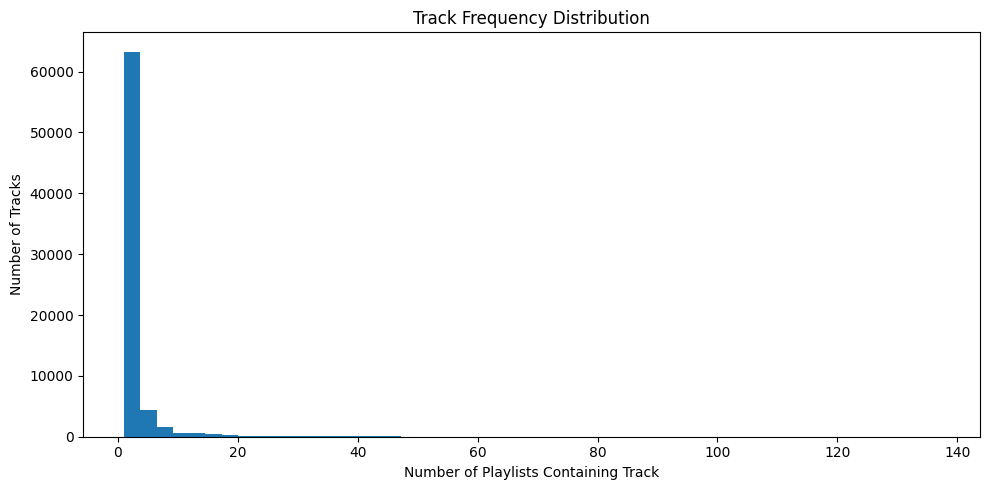

In [ ]:
def plot_track_frequency_distribution(playlist_tracks_df):
    track_frequency = playlist_tracks_df["track_uri"].value_counts()

    print(f"Track frequency stats:\n{track_frequency.head(10)}")

    plt.figure(figsize=(10, 5))
    plt.hist(track_frequency, bins=50)
    plt.xlabel("Number of Playlists Containing Track")
    plt.ylabel("Number of Tracks")
    plt.title("Track Frequency Distribution")
    plt.tight_layout()
    plt.show()


plot_track_frequency_distribution(playlist_tracks_df)

Strong clustering centred around 0 demonstartes the power law problem. The majority of tracks appear in few playlists.

### Power Law Check (Log-Log Plot)

Music streaming data almost always follows a power law
On a **log-log plot**, a power law becomes a straight line. The slope of the line is `-α` (the power law exponent). A steep slope (α > 2) means cold-start dominates and implicit feedback models with confidence weighting are required.

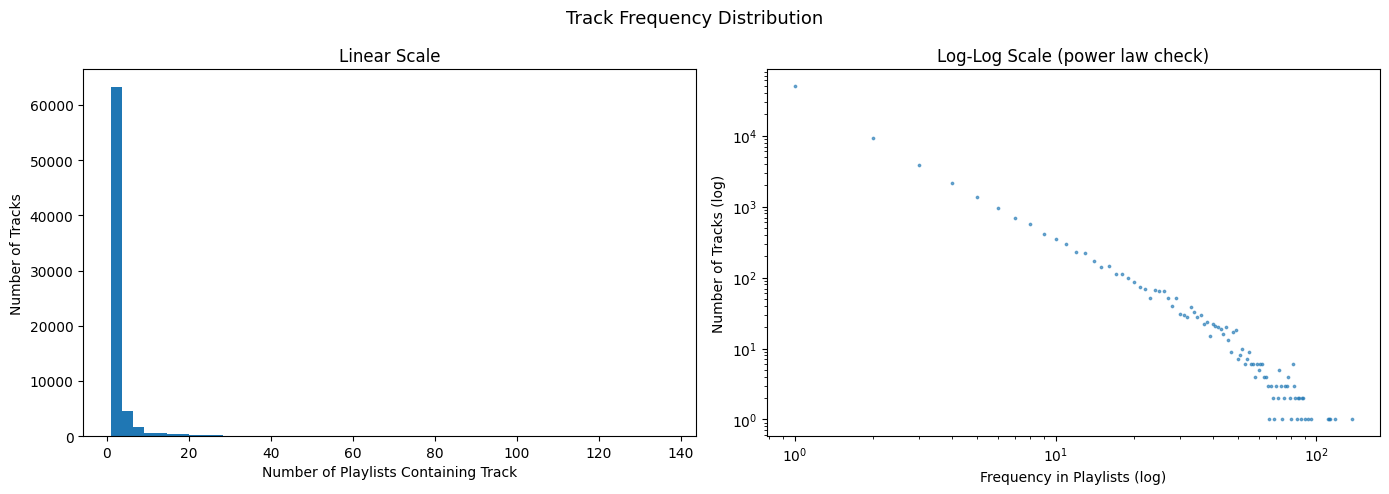

In [12]:
def plot_track_frequency_log_log(playlist_tracks_df):
    track_frequency = playlist_tracks_df["track_uri"].value_counts()
    # Frequency of frequencies: how many tracks appear exactly k times?
    freq_of_freq = track_frequency.value_counts().sort_index()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Linear scale
    ax1.hist(track_frequency, bins=50)
    ax1.set_xlabel("Number of Playlists Containing Track")
    ax1.set_ylabel("Number of Tracks")
    ax1.set_title("Linear Scale")

    # Log-log -> straight line = power law
    ax2.scatter(freq_of_freq.index, freq_of_freq.values, s=3, alpha=0.6)
    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_xlabel("Frequency in Playlists (log)")
    ax2.set_ylabel("Number of Tracks (log)")
    ax2.set_title("Log-Log Scale (power law check)")

    plt.suptitle("Track Frequency Distribution", fontsize=13)
    plt.tight_layout()
    plt.show()


plot_track_frequency_log_log(playlist_tracks_df)

## 4. Playlist Level Analysis

Understanding the structure of playlists informs how to split train/test data and whether minimum interaction thresholds are needed before training.

In [13]:
def plot_tracks_per_playlist(playlist_tracks_df):
    counts = playlist_tracks_df.groupby("playlist_id")["track_uri"].nunique()
    plt.figure(figsize=(10, 5))
    plt.hist(counts, bins=50)
    plt.xlabel("Number of Unique Tracks")
    plt.ylabel("Number of Playlists")
    plt.title("Distribution of Unique Tracks per Playlist")
    plt.tight_layout()
    plt.show()


def count_playlists_below_min_tracks(playlists_df, min_tracks=10):
    return (playlists_df["num_tracks"] < min_tracks).sum()


def plot_playlist_duration(playlists_df):
    duration_mins = playlists_df["duration_ms"] / 60_000
    plt.figure(figsize=(10, 5))
    plt.hist(duration_mins, bins=50)
    plt.xlabel("Duration (minutes)")
    plt.ylabel("Number of Playlists")
    plt.title("Distribution of Playlist Duration")
    plt.tight_layout()
    plt.show()


def plot_edits_per_playlist(playlists_df):
    plt.figure(figsize=(10, 5))
    plt.hist(playlists_df["num_edits"], bins=50)
    plt.xlabel("Number of Edits")
    plt.ylabel("Number of Playlists")
    plt.title("Distribution of Edits per Playlist")
    plt.tight_layout()
    plt.show()


def plot_albums_per_playlist(playlists_df):
    plt.figure(figsize=(10, 5))
    plt.hist(playlists_df["num_albums"], bins=50)
    plt.xlabel("Number of Albums")
    plt.ylabel("Number of Playlists")
    plt.title("Distribution of Albums per Playlist")
    plt.tight_layout()
    plt.show()

Playlists with fewer than 10 tracks: 109 (3.6%)
These will likely be excluded from training or used only as test targets


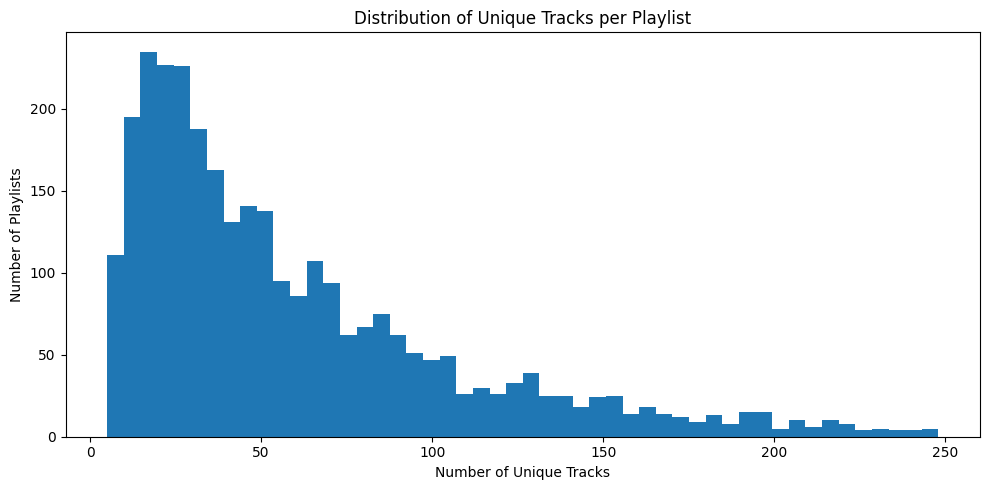

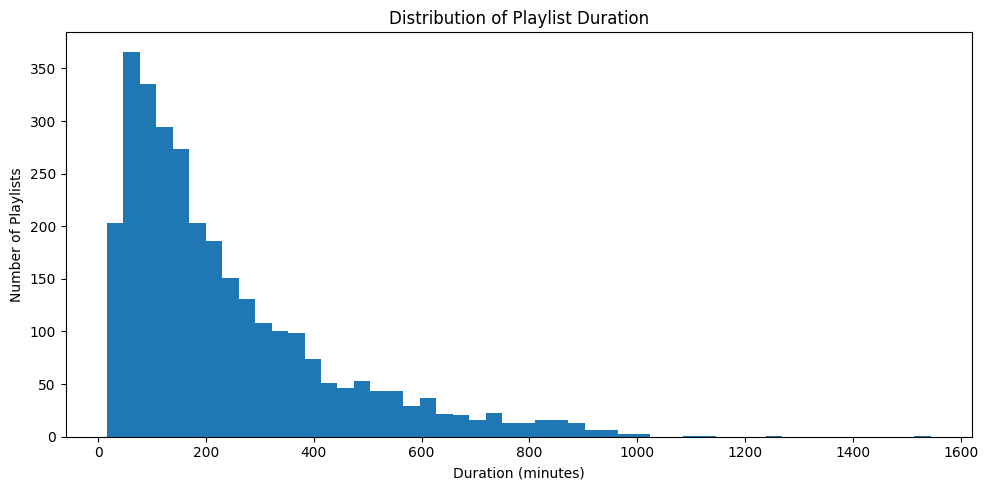

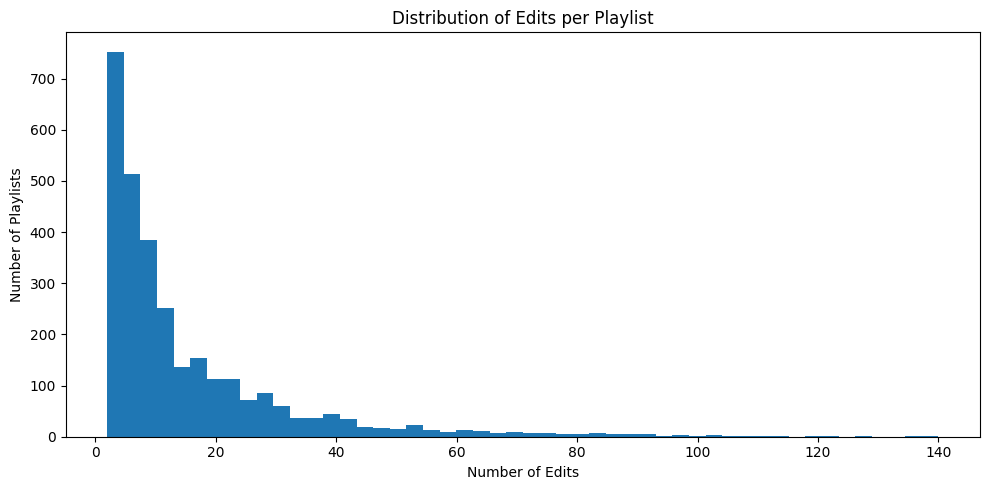

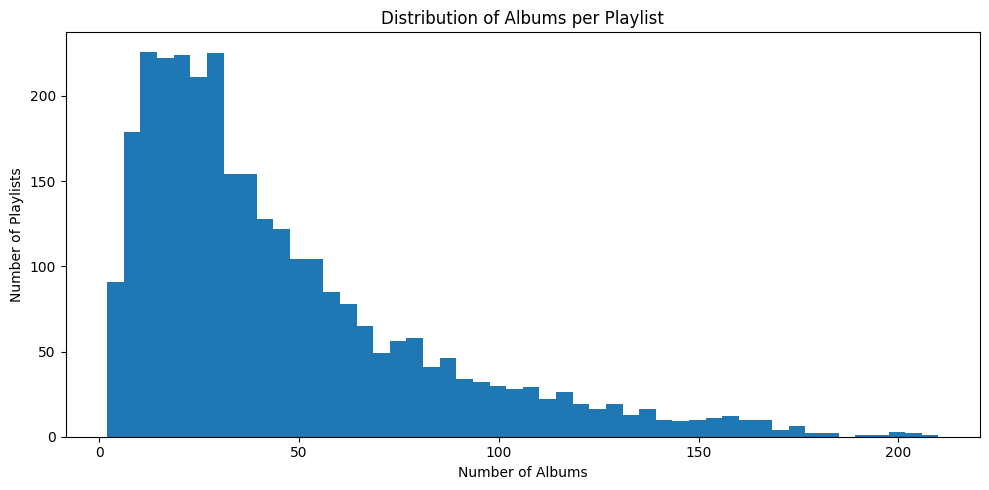

In [14]:
sparse_playlists = count_playlists_below_min_tracks(playlists_df, min_tracks=10)
print(f"Playlists with fewer than 10 tracks: {sparse_playlists:,} ({sparse_playlists/len(playlists_df):.1%})")
print("These will likely be excluded from training or used only as test targets")

plot_tracks_per_playlist(playlist_tracks_df)
plot_playlist_duration(playlists_df)
plot_edits_per_playlist(playlists_df)
plot_albums_per_playlist(playlists_df)

## 5. Track Level Analysis

Track-level analysis looks at popularity and duration distributions across the catalogue.

In [15]:
def top_tracks_by_playlist_occurrence(playlist_tracks_df, n=20):
    return playlist_tracks_df["track_uri"].value_counts().head(n)


def plot_track_duration(tracks_df):
    duration_mins = tracks_df["duration_ms"] / 60_000
    plt.figure(figsize=(10, 5))
    plt.hist(duration_mins, bins=50)
    plt.xlabel("Duration (minutes)")
    plt.ylabel("Number of Tracks")
    plt.title("Distribution of Track Duration")
    plt.tight_layout()
    plt.show()

Top 20 tracks by playlist occurrence:


,playlist_count
track_uri,
spotify:track:1xznGGDReH1oQq0xzbwXa3,137
spotify:track:7KXjTSCq5nL1LoYtL7XAwS,118
spotify:track:7yyRTcZmCiyzzJlNzGC9Ol,113
spotify:track:3a1lNhkSLSkpJE4MSHpDu9,112
spotify:track:7BKLCZ1jbUBVqRi2FVlTVw,111
spotify:track:25khomWgBVamSdKw7hzm3l,95
spotify:track:5hTpBe8h35rJ67eAWHQsJx,93
spotify:track:27GmP9AWRs744SzKcpJsTZ,90
spotify:track:2EEeOnHehOozLq4aS0n6SL,89


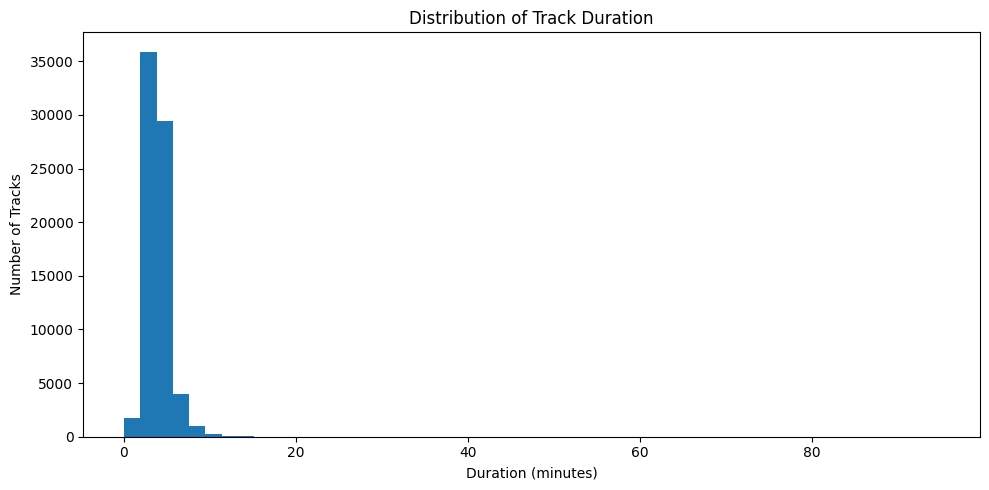

In [16]:
print("Top 20 tracks by playlist occurrence:")
display(top_tracks_by_playlist_occurrence(playlist_tracks_df).to_frame("playlist_count"))

plot_track_duration(tracks_df)

## 6. Artist and Album Analysis

Artist and album concentration matters for CF because it tells us whether side information (artist, album) would improve recommendations. If the top artists account for a disproportionate share of interactions, a hybrid model incorporating artist embeddings (e.g. LightFM) may outperform pure CF.

In [17]:
def top_artists(playlist_tracks_df, n=20):
    return playlist_tracks_df["artist_uri"].value_counts().head(n)


def plot_artist_frequency(playlist_tracks_df):
    artist_frequency = playlist_tracks_df["artist_uri"].value_counts()
    freq_of_freq = artist_frequency.value_counts().sort_index()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.hist(artist_frequency, bins=50)
    ax1.set_xlabel("Number of Playlists Containing Artist")
    ax1.set_ylabel("Number of Artists")
    ax1.set_title("Artist Frequency (Linear)")

    ax2.scatter(freq_of_freq.index, freq_of_freq.values, s=3, alpha=0.6)
    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_xlabel("Frequency in Playlists (log)")
    ax2.set_ylabel("Number of Artists (log)")
    ax2.set_title("Artist Frequency (Log-Log)")

    plt.suptitle("Artist Frequency Distribution", fontsize=13)
    plt.tight_layout()
    plt.show()


def top_albums(playlist_tracks_df, tracks_df, n=20):
    merged = playlist_tracks_df.merge(tracks_df, on="track_uri", how="left")
    return merged["album_name"].value_counts().head(n)


def plot_album_frequency(playlist_tracks_df, tracks_df):
    merged = playlist_tracks_df.merge(tracks_df, on="track_uri", how="left")
    album_frequency = merged["album_name"].value_counts()

    plt.figure(figsize=(10, 5))
    plt.hist(album_frequency, bins=50)
    plt.xlabel("Number of Playlists Containing Album")
    plt.ylabel("Number of Albums")
    plt.title("Distribution of Album Frequency Across Playlists")
    plt.tight_layout()
    plt.show()

In [18]:
print("Top 20 artists by playlist occurrence:")
display(top_artists(playlist_tracks_df).to_frame("playlist_count"))
plot_artist_frequency(playlist_tracks_df)

print("\nTop 20 albums by playlist occurrence:")
display(top_albums(playlist_tracks_df, tracks_df).to_frame("playlist_count"))
plot_album_frequency(playlist_tracks_df, tracks_df)

Top 20 artists by playlist occurrence:


KeyError: 'artist_uri'

## 7. CF Model Selection Summary

Fill in the observed values from the cells above and use the table to guide model selection.

| Metric | Observed | Threshold | Implication |
|---|---|---|---|
| Sparsity | __%  | >99.9% | Implicit feedback models (ALS, BPR) required |
| Cold-start tracks (<5 playlists) | __% of catalogue | >30% | Content-based fallback needed |
| Top 1% track concentration | __% of interactions | >50% | Popularity debiasing needed (BPR or frequency dampening) |
| Playlists with <10 tracks | __% | >20% | Filter from training set |
| Power law on log-log | Straight line? | Yes | Confirms implicit feedback assumption |

**Model shortlist based on findings:**

- If sparsity >99.9% and cold-start is severe: **iALS (implicit ALS)** with confidence weighting + content-based fallback for cold-start items
- If popularity concentration is high: **BPR (Bayesian Personalised Ranking)** — optimises ranking directly and naturally handles popularity bias better than ALS
- If artist/album concentration mirrors track concentration: **LightFM** (hybrid MF with side features) — uses artist/album embeddings alongside interaction data